In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)




Environment ready!
NumPy: 2.2.6
pandas: 2.3.3
scikit-learn: 1.7.2


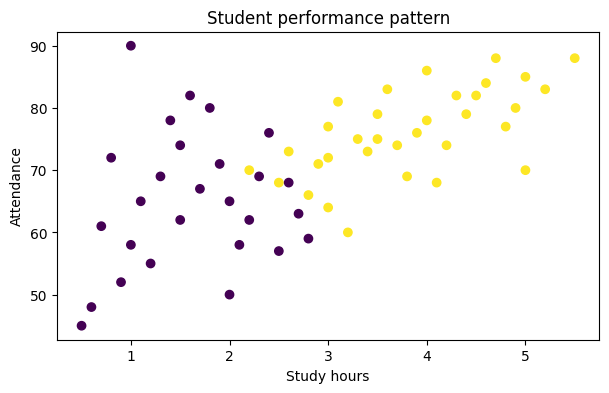

X shape: (60, 3)
y shape: (60,)
Training rows: 48
Testing rows : 12
Model trained!


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("student_performance_new.csv")
df.head()

df.groupby("result")[["study_hours","attendance","assignments"]].mean()

plt.figure(figsize=(7,4))
plt.scatter(df["study_hours"], df["attendance"], c=df["result"])
plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student performance pattern")
plt.show()



X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]



print("X shape:", X.shape)
print("y shape:", y.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")


In [10]:
predictions = model.predict(X_test)

print('predictions:')
print(predictions)
print("X_test")
print(X_test)

predictions:
[0 1 1 1 1 0 1 0 1 0 1 0]
X_test
    study_hours  attendance  assignments
34          0.9          52            6
46          4.1          68            9
15          4.2          74            8
25          5.0          70            9
54          5.2          83           10
45          1.6          82            4
42          4.9          80           10
26          1.7          67            6
48          3.3          75            7
17          1.8          80            5
27          3.6          83            8
19          2.0          50            7


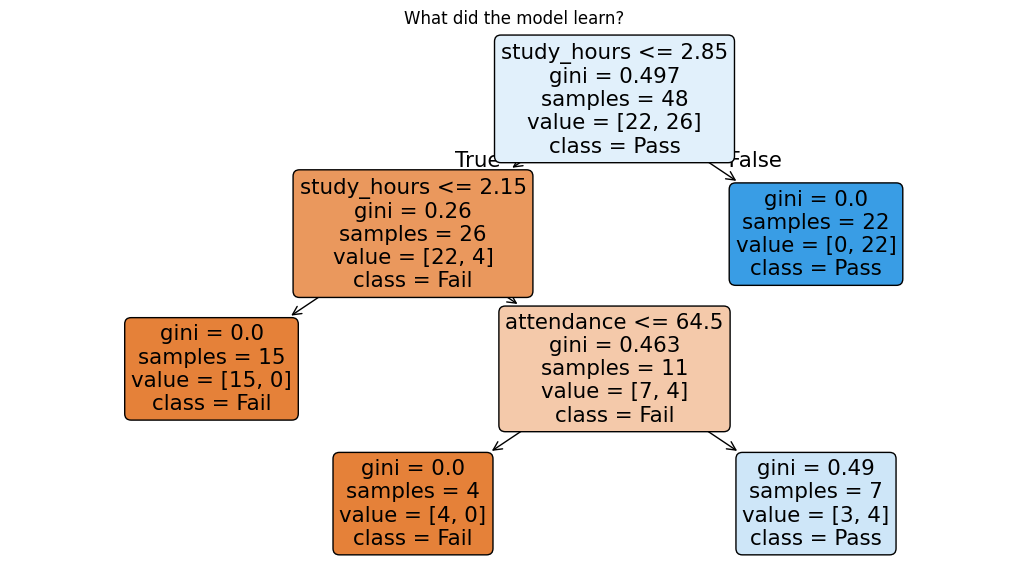

In [11]:
plt.figure(figsize=(13,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("What did the model learn?")
plt.show()


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


Dataset shape: (98, 25)
   Unnamed: 0     id  Gender      Customer Type  Age   Type of Travel  \
0           0  19556  Female     Loyal Customer   52  Business travel   
1           1  90035  Female     Loyal Customer   36  Business travel   
2           2  12360    Male  disloyal Customer   20  Business travel   
3           3  77959    Male     Loyal Customer   44  Business travel   
4           4  36875  Female     Loyal Customer   49  Business travel   

      Class  Flight Distance  Inflight wifi service  \
0       Eco              160                      5   
1  Business             2863                      1   
2       Eco              192                      2   
3  Business             3377                      0   
4       Eco             1182                      2   

   Departure/Arrival time convenient  ...  Inflight entertainment  \
0                                  4  ...                       5   
1                                  1  ...                       4   

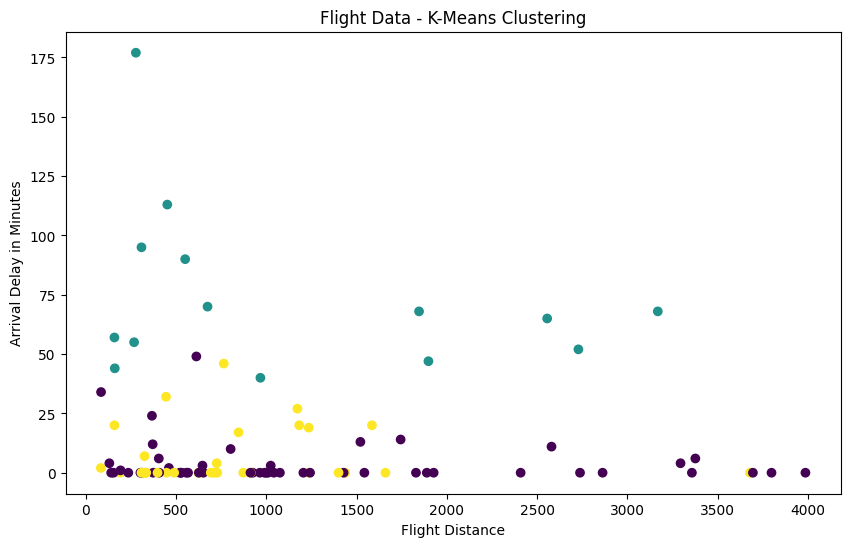

In [4]:
# 1. Load the dataset

df = pd.read_csv("FlightsData.csv")

print("Dataset shape:", df.shape)
print(df.head())


# 2. Select features for clustering

X = df[
[
"Age","Flight Distance","Inflight wifi service","Online boarding","Seat comfort","Departure Delay in Minutes",
"Arrival Delay in Minutes"
]
]

# 3. Handle missing values
X = X.fillna(X.mean())


# 4. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 5. Create K-Means model
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)


# 6. Train the model
kmeans.fit(X_scaled)


# 7. Get cluster labels
df["cluster"] = kmeans.labels_


# 8. Display passengers with their clusters

print("\nPassengers and their clusters:")

print(
df[
["id","Age","Flight Distance","Inflight wifi service","Online boarding","Seat comfort","Departure Delay in Minutes",
"Arrival Delay in Minutes",
"cluster"
]
].to_string(index=False)
)


# 9. Count passengers in each cluster
print("\nNumber of passengers in each cluster:")

print(df["cluster"].value_counts().sort_index())


# 10. Visualize clusters

plt.figure(figsize=(10, 6))

plt.scatter(df["Flight Distance"],df["Arrival Delay in Minutes"],c=df["cluster"])

plt.xlabel("Flight Distance")
plt.ylabel("Arrival Delay in Minutes")
plt.title("Flight Data - K-Means Clustering")

plt.show()